---
title: "Superposition in a Toy word2vec: Three Attributes, Two Dimensions"
description: |
  A model can represent more features than it has dimensions. This is the geometry it uses to do
  it, and what it costs when the features have to share.
author: Rosh Beed
date: '2026-07-20'
categories:
  - nlp
  - embeddings
  - interpretability
  - deep-dive
jupyter: python3
---


[Week 1](../2026-06-08-word2vec-from-scratch/) trained word2vec on 17 million words
and the co-occurrence structure came from whatever people happened to write. This
post does the opposite. I hand-build a tiny corpus so the structure is exactly what
I want, then give the model fewer dimensions than it needs and watch what it does.

The idea comes from Anthropic's [Toy Models of
Superposition](https://transformer-circuits.pub/2022/toy_model/index.html). A model
can represent more features than it has dimensions by packing feature directions
into the same space, instead of giving each one its own axis. I wanted to see it
happen.

## The Setup

Three attributes, two values each:

| Attribute | Values |
|---|---|
| Status | `noble` / `common` |
| Gender | `masc` / `fem` |
| Age | `adult` / `young` |

Combined, they give eight words:

```text
king     = noble  + masc + adult      queen    = noble  + fem + adult
man      = common + masc + adult      woman    = common + fem + adult
prince   = noble  + masc + young      princess = noble  + fem + young
boy      = common + masc + young      girl     = common + fem + young
```

Each of the six attribute values gets its own word, which I will call a **pole**.
Each of the eight words above co-occurs with its three poles.

The corpus is built from a cycle. The six poles sit in a ring, arranged so that
opposites are three steps apart:

```text
noble — masc — adult — common — fem — young — noble
```

That ring is what spreads the poles out evenly. Each pole also gets a self-loop,
and each corner word touches only its own three poles, once each. Sixty-six
co-occurrence pairs in total.

In [1]:
# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax


import numpy as np

from itertools import combinations

POLES = ["noble", "common", "masc", "fem", "adult", "young"]
SYNONYMS = {
    "noble": ["royal", "crown", "regal"],  "common": ["peasant", "serf", "lowly"],
    "masc":  ["he", "him", "his"],         "fem":    ["she", "her", "hers"],
    "adult": ["grown", "elder", "mature"], "young":  ["child", "youth", "junior"],
}
CYCLE = ["noble", "masc", "adult", "common", "fem", "young"]   # opposites 3 apart
CORNERS = {
    "king":   ("noble", "masc", "adult"),  "queen":    ("noble", "fem", "adult"),
    "man":    ("common", "masc", "adult"), "woman":    ("common", "fem", "adult"),
    "prince": ("noble", "masc", "young"),  "princess": ("noble", "fem", "young"),
    "boy":    ("common", "masc", "young"), "girl":     ("common", "fem", "young"),
}

def sparse_corpus():
    """The pole cycle, self-loops, and each corner touching only its own poles."""
    corpus = [f"{CYCLE[i]} {CYCLE[(i + 1) % 6]}" for i in range(6)] * 2
    corpus += [f"{p} {p}" for p in POLES]
    for corner, poles in CORNERS.items():
        for p in poles:
            corpus += [f"{corner} {p}", f"{p} {corner}"]
    return corpus

print(f"{len(sparse_corpus())} co-occurrence pairs, "
      f"{len({w for s in sparse_corpus() for w in s.split()})} words")


66 co-occurrence pairs, 14 words


The model is skip-gram with negative sampling, the training method word2vec
actually uses, written out in plain numpy. Every word gets a vector. For each word,
pull it toward the words it appears next to and push it away from a random word it
doesn't.

Be clear about what is designed here and what is not. The ring is designed: I put
opposites three steps apart, and a six-cycle laid out in a plane is a hexagon, so
the model is handed a strong hint about where the poles should go.

What is not designed is the geometry. Nothing in the corpus mentions a dimension, an
angle or a direction. The model only ever sees which words sit next to which. That
opposites come out antipodal, that the three axes settle 60° apart, and that two
specific words cancel to nothing are all consequences of the counting.

In [2]:
def train(corpus, dim, seed=9, window=2, lr0=0.01, epochs=2000):
    vocab = sorted({w for s in corpus for w in s.split()})
    index = {w: i for i, w in enumerate(vocab)}

    pairs = [(c, x) for s in corpus
             for ids in [[index[w] for w in s.split()]]
             for i, c in enumerate(ids) for j, x in enumerate(ids)
             if 0 < abs(i - j) <= window]

    counts = np.array([sum(s.split().count(w) for s in corpus) for w in vocab], float)
    unigram = counts ** 0.75
    unigram /= unigram.sum()

    sigmoid = lambda x: 1 / (1 + np.exp(-np.clip(x, -50, 50)))
    rng = np.random.RandomState(seed)
    W_in = rng.uniform(-0.5 / dim, 0.5 / dim, (len(vocab), dim))
    W_out = rng.uniform(-0.5 / dim, 0.5 / dim, (len(vocab), dim))

    for epoch in range(epochs):
        lr = lr0 * (1 - epoch / epochs)
        for centre, context in pairs:
            negatives = rng.choice(len(vocab), size=1, p=unigram)
            negatives = negatives[negatives != context]
            targets = np.concatenate(([context], negatives))
            labels = np.r_[1, [0] * (len(targets) - 1)]
            error = sigmoid(W_in[centre] @ W_out[targets].T) - labels
            W_out[targets] -= lr * np.outer(error, W_in[centre])
            W_in[centre] -= lr * (error @ W_out[targets])

    return {w: v for w, v in zip(vocab, W_in - W_in.mean(0))}

## Three Dimensions

Three attributes suggests three dimensions, one per attribute. Train it that way
first and that is what you get: the three attribute directions come out near
perpendicular, nothing has to share, and every analogy lands on the right word.

In [3]:
def pole(vectors, name):
    """The dense corpus has no token named after its pole, so average its synonyms."""
    if name in vectors:
        return vectors[name]
    return np.mean([vectors[t] for t in SYNONYMS[name]], axis=0)

def axis(vectors, a, b):
    """The direction an attribute points, from one pole to its opposite."""
    d = pole(vectors, a) - pole(vectors, b)
    return d / np.linalg.norm(d)

AXES = {"status": ("noble", "common"), "gender": ("masc", "fem"), "age": ("adult", "young")}

vectors_3d = train(sparse_corpus(), dim=3)
directions = {name: axis(vectors_3d, a, b) for name, (a, b) in AXES.items()}

names = list(AXES)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        angle = np.degrees(np.arccos(np.clip(directions[a] @ directions[b], -1, 1)))
        print(f"{a:>7} to {b:<7} {angle:6.1f} degrees apart")

 status to gender    80.1 degrees apart
 status to age       99.1 degrees apart
 gender to age       80.3 degrees apart


Near enough to right angles. Each attribute has an axis to itself.

## Two Dimensions

Now take one away. Same eight words, same three attributes, one fewer dimension to
put them in.

In [4]:
vectors = train(sparse_corpus(), dim=2)

print("pole angles, measured from the x axis\n")
for p in sorted(POLES, key=lambda p: np.degrees(np.arctan2(*vectors[p][::-1])) % 360):
    print(f"  {p:<8} {np.degrees(np.arctan2(*vectors[p][::-1])) % 360:7.1f}")

print()
for name, (a, b) in AXES.items():
    v, w = vectors[a], vectors[b]
    opposite = np.degrees(np.arccos(np.clip(v @ w / (np.linalg.norm(v) * np.linalg.norm(w)), -1, 1)))
    print(f"  {a:>6} to {b:<8} {opposite:6.1f} degrees")

pole angles, measured from the x axis

  noble       11.4
  masc        71.2
  adult      133.1
  common     192.5
  fem        251.4
  young      312.7

   noble to common    178.9 degrees
    masc to fem       179.8 degrees
   adult to young     179.6 degrees


The six poles have spread into a hexagon. Each attribute is still an opposite pair,
near enough antipodal. But the three axes now sit 60 degrees apart rather than 90.

They cannot be perpendicular any more, so they share the plane. Three attributes
represented in a space with room for two, paid for by giving up the right angles.
That's superposition.

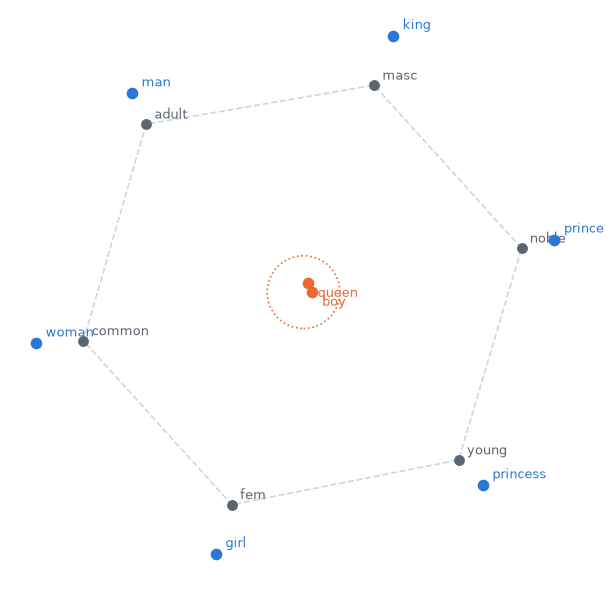

In [5]:
#| label: fig-hexagon
#| fig-cap: Three attributes in two dimensions. The six poles spread into a hexagon, and two of the eight corner words have been cancelled to the origin.
#| fig-alt: A scatter plot. Six pole words sit evenly around a dashed hexagon, and six corner words sit just outside it, each near the poles it is made of. The remaining two corner words, queen and boy, sit on top of each other at the centre, inside a dotted circle.

import matplotlib.pyplot as plt

fig, ax = figure(width=6.6, height=6.0)

ring = np.array([vectors[p] for p in CYCLE + [CYCLE[0]]])
ax.plot(ring[:, 0], ring[:, 1], color="#cfd6de", linewidth=1.2, linestyle="--", zorder=1)

for p in POLES:
    x, y = vectors[p]
    ax.scatter(x, y, s=46, color=MUTED, zorder=3)
    ax.annotate(p, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=9, color=MUTED)

for corner in CORNERS:
    x, y = vectors[corner]
    faded = np.linalg.norm(vectors[corner]) < 0.5
    ax.scatter(x, y, s=54, color=COLOURS[1] if faded else COLOURS[0], zorder=4)
    ax.annotate(corner, (x, y), xytext=(7, -10 if faded else 5),
                textcoords="offset points", fontsize=9,
                color=COLOURS[1] if faded else COLOURS[0])

ax.add_patch(plt.Circle((0, 0), 0.22, fill=False, linestyle=":", color=COLOURS[1], linewidth=1.2))
ax.set_aspect("equal")
style_axes(ax, grid=None)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout()

## Two Words Disappear

Look at the middle of that plot. `queen` and `boy` are sitting on the origin, on
top of each other, despite sharing no attributes at all.

They have not drifted there. They have been cancelled.

In [6]:
for corner in sorted(CORNERS, key=lambda c: np.linalg.norm(vectors[c])):
    print(f"  {corner:<9} {np.linalg.norm(vectors[corner]):.3f}")

  boy       0.054
  queen     0.061
  prince    1.549
  man       1.589
  princess  1.594
  king      1.642
  woman     1.648
  girl      1.671


Six words sit out at about 1.6. Two are at 0.05.

A corner word is only ever pulled toward its own three poles, so where it ends up is
decided by where those three point. Add them up and compare:

In [7]:
print(f"{'corner':<10}{'|sum of its poles|':>20}{'|the corner|':>15}{'aligned':>10}")
for corner, poles in CORNERS.items():
    total = sum(vectors[p] for p in poles)
    length, corner_length = np.linalg.norm(total), np.linalg.norm(vectors[corner])
    print(f"{corner:<10}{length:>20.3f}{corner_length:>15.3f}"
          f"{total @ vectors[corner] / (length * corner_length):>+10.2f}")


corner      |sum of its poles|   |the corner|   aligned
king                     2.654          1.642     +1.00
queen                    0.067          0.061     -0.50
man                      2.710          1.589     +1.00
woman                    2.776          1.648     +1.00
prince                   2.730          1.549     +1.00
princess                 2.733          1.594     +1.00
boy                      0.067          0.054     +0.48
girl                     2.724          1.671     +1.00


For six of the eight, the three poles add to something long and the corner sits
along it at roughly 60% of the length. For `queen` and `boy` that same sum is a
fortieth of the size. Nothing cancelled those two corners; their poles cancelled
each other before the corner got there.

Ignore the last column on those two rows. It is the angle between two vectors that
are both essentially zero, so it can come out at anything.

The hexagon says why. `queen` is `noble + fem + adult`, which sit at 11°, 251° and
133° — each pair 120° apart. Three vectors of roughly equal length at 120° sum to
nothing. `boy` is `common + masc + young`, the same tripod rotated.

Those are the only two corners this happens to, and it is not luck. Go around the
pole cycle taking every other pole and you get exactly two triples,
`{noble, adult, fem}` and `{common, masc, young}`. Every other corner takes three
poles spanning a 120° arc, which add up constructively instead.

So you can predict which two words will vanish by looking at the cycle, before you
train anything. I didn't expect that. I assumed interference would show up as
general noise. Instead it picked two specific words and deleted them.

## The Analogies Still Pass

Take the predicted point, look up its nearest word, and every analogy comes back
correct.

In [8]:
TESTS = [("king", "man", "woman", "queen"), ("king", "prince", "princess", "queen"),
         ("man", "king", "prince", "boy"), ("king", "queen", "woman", "man"),
         ("prince", "boy", "girl", "princess")]

print(f"{'analogy':<32}{'nearest':>10}{'error':>8}{'margin':>9}")
for a, b, c, expected in TESTS:
    target = vectors[a] - vectors[b] + vectors[c]
    ranked = sorted(((np.linalg.norm(vectors[w] - target), w) for w in CORNERS))
    (err, nearest), (runner_up, _) = ranked[0], ranked[1]
    flag = "" if nearest == expected else "  <- wrong"
    print(f"{a + ' - ' + b + ' + ' + c:<32}{nearest:>10}{err:>8.3f}{runner_up - err:>9.3f}{flag}")

analogy                            nearest   error   margin
king - man + woman                   queen   0.069    0.031
king - prince + princess             queen   0.082    0.001
man - king + prince                    boy   0.120    0.003
king - queen + woman                   man   0.069    1.511
prince - boy + girl               princess   0.182    1.315


Every one is right. Look at the margins.

The bottom two beat their runner-up by well over a point. They are in no danger.
The middle two win by a thousandth. A model doesn't get an answer right by that
margin. A coin lands on its edge by that margin.

Both of the close ones are aiming at `queen` or `boy`, the two words sitting on the
origin a fraction apart. Anything pointing at one of them is choosing between two
words that are, for practical purposes, in the same place.

And the coin does land the other way. Re-running the same corpus at eleven other
seeds gives twelve different collapses, and the close analogies come back as the
wrong word in ten of the twelve.

In [9]:
SEEDS = (9, 21, 13, 6, 2, 23, 16, 1, 10, 18, 20, 15)

def misreads(vs):
    """How many of the five analogies come back as the wrong word."""
    wrong = 0
    for a, b, c, expected in TESTS:
        target = vs[a] - vs[b] + vs[c]
        wrong += min((np.linalg.norm(vs[w] - target), w) for w in CORNERS)[1] != expected
    return wrong

runs = sorted((min(np.linalg.norm(v[c]) for c in CORNERS), misreads(v), seed)
              for seed in SEEDS
              for v in [train(sparse_corpus(), dim=2, seed=seed)])

print(f"{'smallest corner':>16}{'seed':>7}{'of 5 misread':>15}")
for smallest, wrong, seed in runs:
    print(f"{smallest:>16.3f}{seed:>7}{wrong:>15}")

half = len(runs) // 2
worst = np.mean([r[1] for r in runs[:half]])
mildest = np.mean([r[1] for r in runs[half:]])
print(f"\nthe {half} hardest collapses misread {worst:.1f} of 5 on average")
print(f"the {half} mildest collapses misread {mildest:.1f} of 5 on average")


 smallest corner   seed   of 5 misread
           0.054      9              0
           0.200     21              2
           0.284     13              0
           0.413      6              2
           0.441      2              2
           0.442     23              1
           0.451     16              2
           0.507      1              2
           0.539     10              1
           0.543     18              3
           0.545     20              1
           0.554     15              3

the 6 hardest collapses misread 1.2 of 5 on average
the 6 mildest collapses misread 2.0 of 5 on average


Read the two columns against each other. If superposition damaged the embedding in
the way you would expect, the runs with the hardest collapse would be the ones that
fail the analogies. They are not: the relationship runs the other way, weakly, and
the single worst collapse of the twelve gets all five right.

So this is not "worse embedding, worse score". Whether the analogies pass tells you
very little about whether the space behind them is any good.

The three-dimensional model makes the same point from the other side. There the
errors are *larger*, and every answer is nearest its target by a mile. The 2D model
is better at hitting the target and worse at being understood, because in 2D the
target has someone else standing on it.

## The Corpus Decides

None of this works on a corpus you would get by accident.

A denser corpus does not. Give each pole three interchangeable synonym tokens, let
every corner word co-occur with all of them, and add pairs between the synonyms to
hold each pole together: ninety co-occurrence pairs against the sixty-six above.

That works some of the time and not others. On four seeds out of ten, two or three
of the attribute directions end up on the same line.

In [10]:
def dense_corpus():
    """Every corner co-occurs with all three tokens of each of its poles, plus struts."""
    corpus = [f"{corner} {tok}" for corner, poles in CORNERS.items()
              for p in poles for tok in SYNONYMS[p]]
    corpus += [f"{a} {b}" for toks in SYNONYMS.values() for a, b in combinations(toks, 2)]
    return corpus

dense = train(dense_corpus(), dim=2)
dense_dirs = {name: axis(dense, a, b) for name, (a, b) in AXES.items()}

print(f"{'':>18}{'sparse':>9}{'dense':>9}")
names = list(AXES)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        sp = np.degrees(np.arccos(np.clip(axis(vectors, *AXES[a]) @ axis(vectors, *AXES[b]), -1, 1)))
        dn = np.degrees(np.arccos(np.clip(dense_dirs[a] @ dense_dirs[b], -1, 1)))
        print(f"{a + ' to ' + b:>18}{sp:>8.0f}°{dn:>8.0f}°")

                     sparse    dense
  status to gender      59°     179°
     status to age     121°       2°
     gender to age      62°     176°


Same model, same attributes, same seed. Only the corpus changes. In the dense
column the three attribute directions have collapsed onto one line: 179° and 2° are
both "the same axis", just pointing opposite ways.

What fixed it was giving the model **less** to work with, not more. The extra edges
were the problem. Every corner pulling on every synonym of every pole gives the
poles a reason to bunch together, and once two of them bunch there's nothing
holding the third direction apart.

I assumed this was a space problem that a third dimension would fix. It's not. At
three dimensions, with a whole dimension per attribute going spare, the dense
corpus still sits about 27° off orthogonal on average against the sparse corpus's
12°, usually by fusing two attributes onto one axis.

## Conclusion

* A model can represent more features than it has dimensions, by giving up the
  right angles between them
* The cost is interference, and here it is not spread evenly as noise
* It picked two specific words and cancelled them to zero, predictably, from the
  structure of the corpus alone
* The analogy tests still pass, two of them by 0.001
* Passing the test tells you almost nothing about whether the space is any good

That last point is the one I would take anywhere else. The arithmetic still moves
in the right direction, the errors stay small, and the analogies still come back
correct. Superposition does not announce itself.

The code is [on GitHub](https://github.com/RoshBeed/ai-residency), and the idea is
from Anthropic's [Toy Models of
Superposition](https://transformer-circuits.pub/2022/toy_model/index.html).